In [5]:
#STEP 1 :: DATA PRE_PROCESSING AND ANALYSIS

In [6]:

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import model_selection
from sklearn.model_selection import train_test_split

In [7]:

dataset=pd.read_csv('Housing.csv')
     

In [8]:

dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [10]:

dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [11]:

dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:

dataset.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

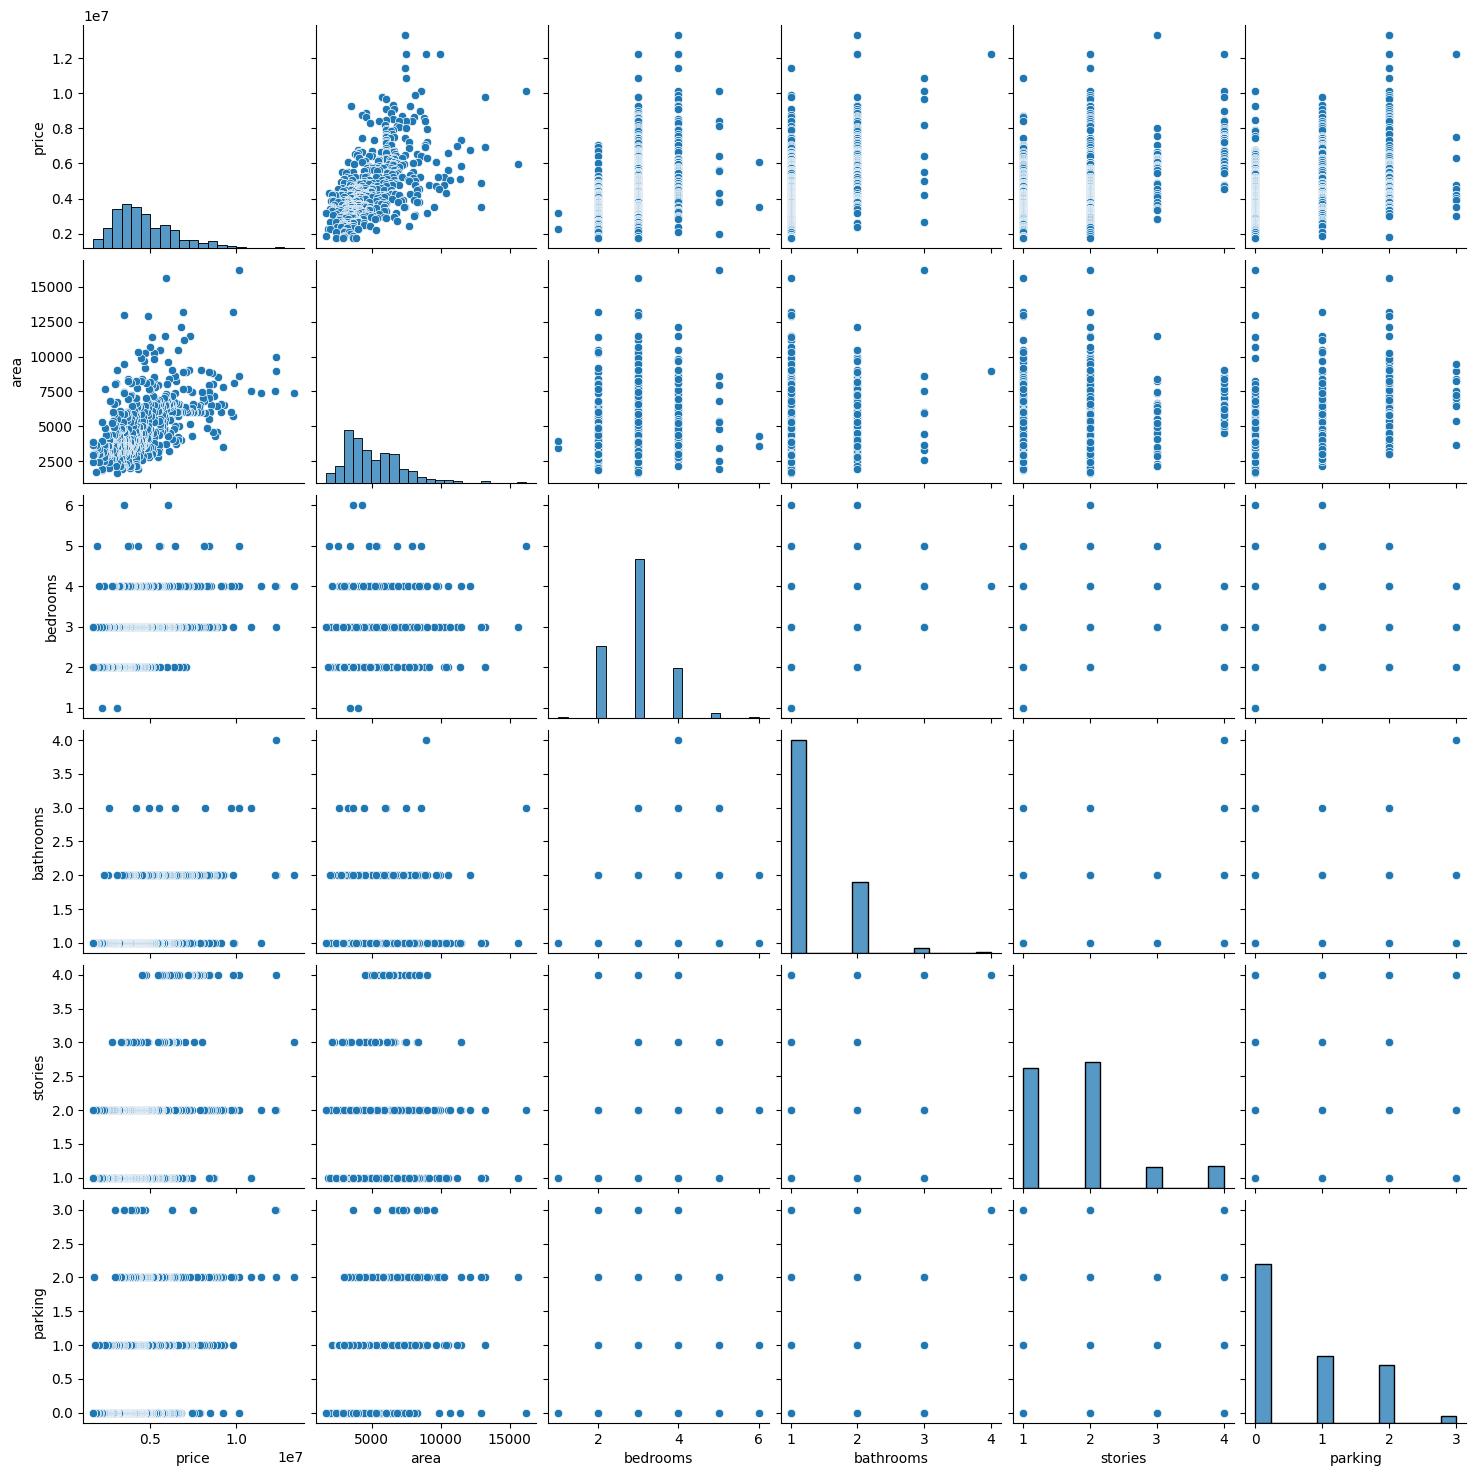

In [13]:

sns.pairplot(dataset)

In [14]:

data=pd.get_dummies(dataset)

In [15]:

data

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,False,True,True,False,...,False,True,False,False,True,False,True,True,False,False
1,12250000,8960,4,4,4,3,False,True,True,False,...,False,True,False,False,True,True,False,True,False,False
2,12250000,9960,3,2,2,2,False,True,True,False,...,True,True,False,True,False,False,True,False,True,False
3,12215000,7500,4,2,2,3,False,True,True,False,...,True,True,False,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,False,True,False,True,...,True,True,False,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,False,True,True,False,...,True,True,False,True,False,True,False,False,False,True
541,1767150,2400,3,1,1,0,True,False,True,False,...,False,True,False,True,False,True,False,False,True,False
542,1750000,3620,2,1,1,0,False,True,True,False,...,False,True,False,True,False,True,False,False,False,True
543,1750000,2910,3,1,1,0,True,False,True,False,...,False,True,False,True,False,True,False,True,False,False


In [16]:
#STEP 2 :: DATA SPLITTING

In [17]:

x=data.drop('price',axis=1)
y=data['price']
     

In [18]:
x

,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,False,True,True,False,True,False,True,False,False,True,False,True,True,False,False
1,8960,4,4,4,3,False,True,True,False,True,False,True,False,False,True,True,False,True,False,False
2,9960,3,2,2,2,False,True,True,False,False,True,True,False,True,False,False,True,False,True,False
3,7500,4,2,2,3,False,True,True,False,False,True,True,False,False,True,False,True,True,False,False
4,7420,4,1,2,2,False,True,False,True,False,True,True,False,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,False,True,True,False,False,True,True,False,True,False,True,False,False,False,True
541,2400,3,1,1,0,True,False,True,False,True,False,True,False,True,False,True,False,False,True,False
542,3620,2,1,1,0,False,True,True,False,True,False,True,False,True,False,True,False,False,False,True
543,2910,3,1,1,0,True,False,True,False,True,False,True,False,True,False,True,False,True,False,False


In [19]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
     

In [21]:
#STEP 3 :: MODEL TRAINING

In [22]:

from sklearn.linear_model import LinearRegression

In [23]:

equation=LinearRegression()
equation.fit(x_train,y_train)

LinearRegression()

In [24]:

equation.intercept_

np.float64(1914654.3559292513)

In [25]:

equation.coef_
     

array([ 2.46645971e+02,  1.28273876e+05,  9.48185824e+05,  4.21335610e+05,
        2.19480760e+05, -2.39130397e+05,  2.39130397e+05, -1.92588053e+05,
        1.92588053e+05, -1.76769792e+05,  1.76769792e+05, -6.24023106e+05,
        6.24023106e+05, -4.54343797e+05,  4.54343797e+05, -3.47296096e+05,
        3.47296096e+05,  1.70946314e+05,  1.03832850e+05, -2.74779165e+05])

In [26]:
y_test_predicted=equation.predict(x_test)
y_test_predicted

array([ 3911453.54064881,  6143880.82335065,  4528631.96120032,
        7232572.78423674,  2812400.75275948,  6934975.9453954 ,
        3226876.31570197,  3237823.37678727,  3490347.53294593,
        8191982.66932562,  6567357.757297  ,  3682106.94173898,
        3842743.61695771,  4517443.56077114,  4046655.54296566,
        1959416.72194195,  4072106.39887932,  3701748.5673852 ,
        3278156.73230395,  4613335.39279988,  5914005.99960493,
        6364142.0464961 ,  4780192.88051162,  2678961.56838776,
        5312597.93805941,  5656577.20183505,  5430554.91520129,
        5552569.00670162,  5702118.36848691,  5824339.78909628,
        3393388.97841732,  6472056.62389444,  7112446.56922114,
        2925984.41409794,  4531135.86406982,  5244195.87246482,
        5038926.2391623 ,  3740632.18496513,  2878434.13401556,
        3965260.89328845,  7940385.80780392,  4886093.89601643,
        6389754.68707428,  3547187.00241673,  3840075.33680728,
        6396360.28556586,  4511778.33005

<Axes: xlabel='price'>

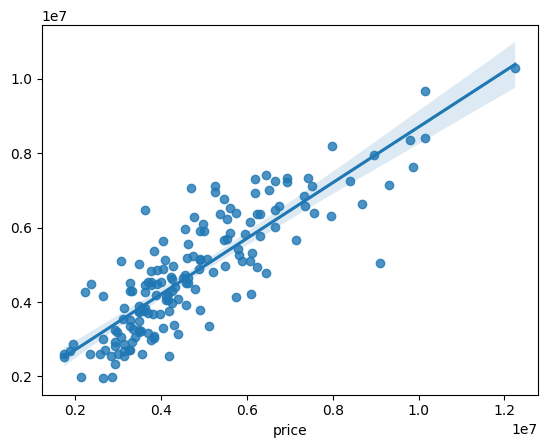

In [27]:

sns.regplot(x=y_test,y=y_test_predicted)

In [28]:
#STEP 4 :: MODEL EVALUATION

In [29]:

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_test_predicted)
mae = mean_absolute_error(y_test, y_test_predicted)
mse = mean_squared_error(y_test, y_test_predicted)
rmse = np.sqrt(mse)

In [30]:

print(f"R-squared: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

R-squared: 0.7245629970975955
Mean Absolute Error (MAE): 731779.3499846344
Mean Squared Error (MSE): 955428862101.2504
Root Mean Squared Error (RMSE): 977460.4145955223
